<a href="https://colab.research.google.com/github/clementeyquem/Linear_Regression/blob/main/Linear_Regression_Module_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import yfinance as yf
import pandas as pd
import numpy as np

# Téléchargement des données (2018–2024)
spx = yf.download("^GSPC", start="2018-01-01", end="2024-12-31", auto_adjust=True)
vix = yf.download("^VIX", start="2018-01-01", end="2024-12-31", auto_adjust=True)
# On garde uniquement le prix de clôture
spx_close = spx['Close'].squeeze() # squeeze() : DataFrame -> Series
vix_close = vix['Close'].squeeze()
print(spx_close.head())
print(f'Nb observations SPX : {len(spx_close)}')

log_ret = np.log(spx_close/spx_close.shift(1))
realized_vol = log_ret.rolling(21).std() * np.sqrt(252) * 100
df = pd.DataFrame({
'VIX' : vix_close,
'RealizedVol': realized_vol}).dropna()
print(df.describe().round(2))
print(f'Shape final : {df.shape}')


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Date
2018-01-02    2695.810059
2018-01-03    2713.060059
2018-01-04    2723.989990
2018-01-05    2743.149902
2018-01-08    2747.709961
Name: ^GSPC, dtype: float64
Nb observations SPX : 1760
           VIX  RealizedVol
count  1739.00      1739.00
mean     19.98        16.58
std       7.70        11.11
min      10.85         5.22
25%      14.64        10.17
50%      18.18        13.82
75%      22.96        20.19
max      82.69        97.56
Shape final : (1739, 2)


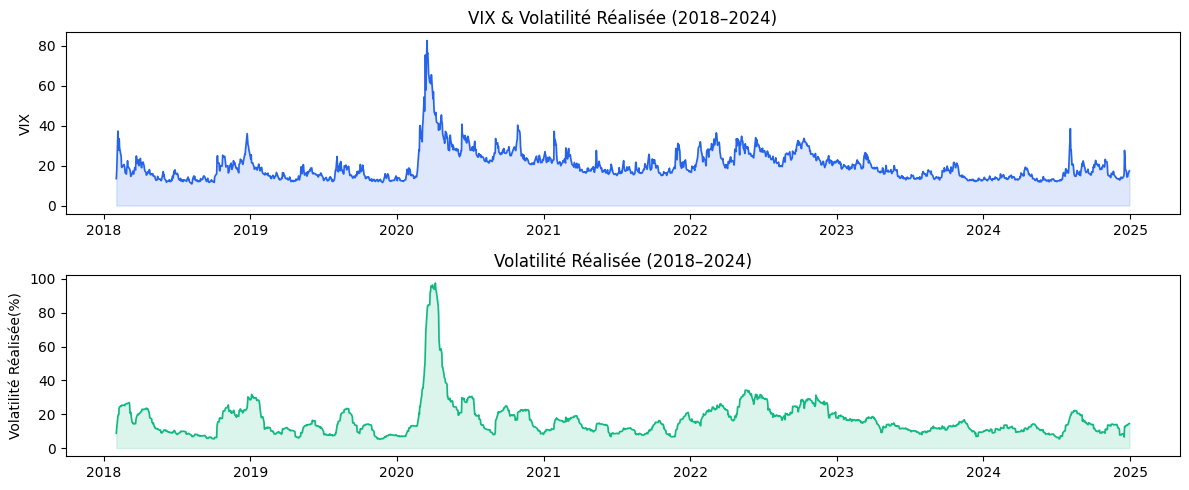

In [37]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 1, figsize=(12, 5))
axes[0].plot(df.index, df['VIX'], color='#2563EB', lw=1.2)
axes[0].fill_between(df.index, df['VIX'], alpha=0.15, color='#2563EB')
axes[0].set_ylabel('VIX')
axes[0].set_title('VIX & Volatilité Réalisée (2018–2024)')
axes[1].plot(df.index, df['RealizedVol'], color='#10B981', lw=1.2)
axes[1].fill_between(df.index, df['RealizedVol'], alpha=0.15, color='#10B981')
axes[1].set_title('Volatilité Réalisée (2018–2024)')
axes[1].set_ylabel('Volatilité Réalisée(%)')
plt.tight_layout() #eviter que des tires etiquettenes ne se chevauchent
plt.show()


In [32]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Préparation des arrays (sklearn attend shape (n,1) pour X)
X = df[['VIX']].values # shape (n, 1)
y = df['RealizedVol'].values # shape (n,)

# Entraînement du modèle
model = LinearRegression()
model.fit(X, y)

# Coefficients
alpha = model.intercept_ # ordonnée à l'origine
beta = model.coef_[0] # pente

print(f'a (intercept) = {alpha:.4f}')
print(f'b (VIX coef) = {beta:.4f}')

# Prédictions
y_pred = model.predict(X)

# R²
r2 = r2_score(y, y_pred)
print(f'R² = {r2:.4f}')

a (intercept) = -7.1116
b (VIX coef) = 1.1860
R² = 0.6747


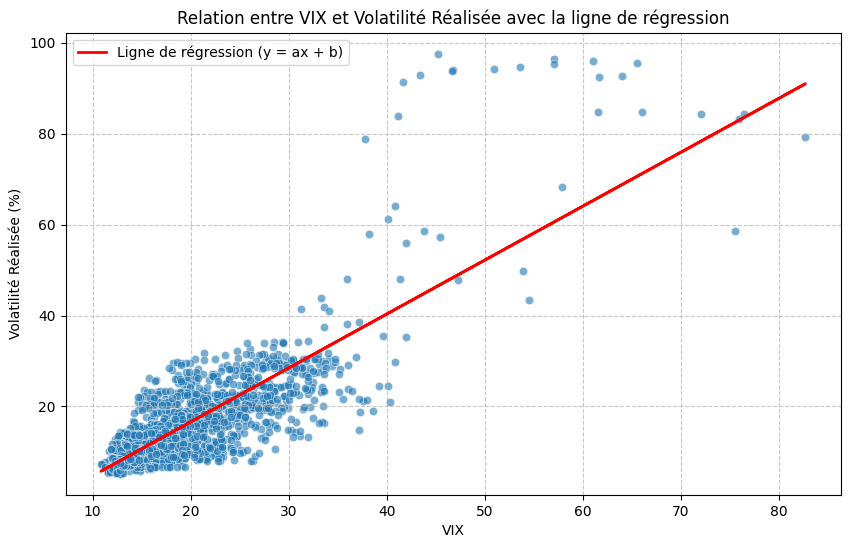

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x='VIX', y='RealizedVol', data=df, alpha=0.6)
plt.plot(X, y_pred, color='red', linewidth=2, label='Ligne de régression (y = ax + b)')
plt.title('Relation entre VIX et Volatilité Réalisée avec la ligne de régression')
plt.xlabel('VIX')
plt.ylabel('Volatilité Réalisée (%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

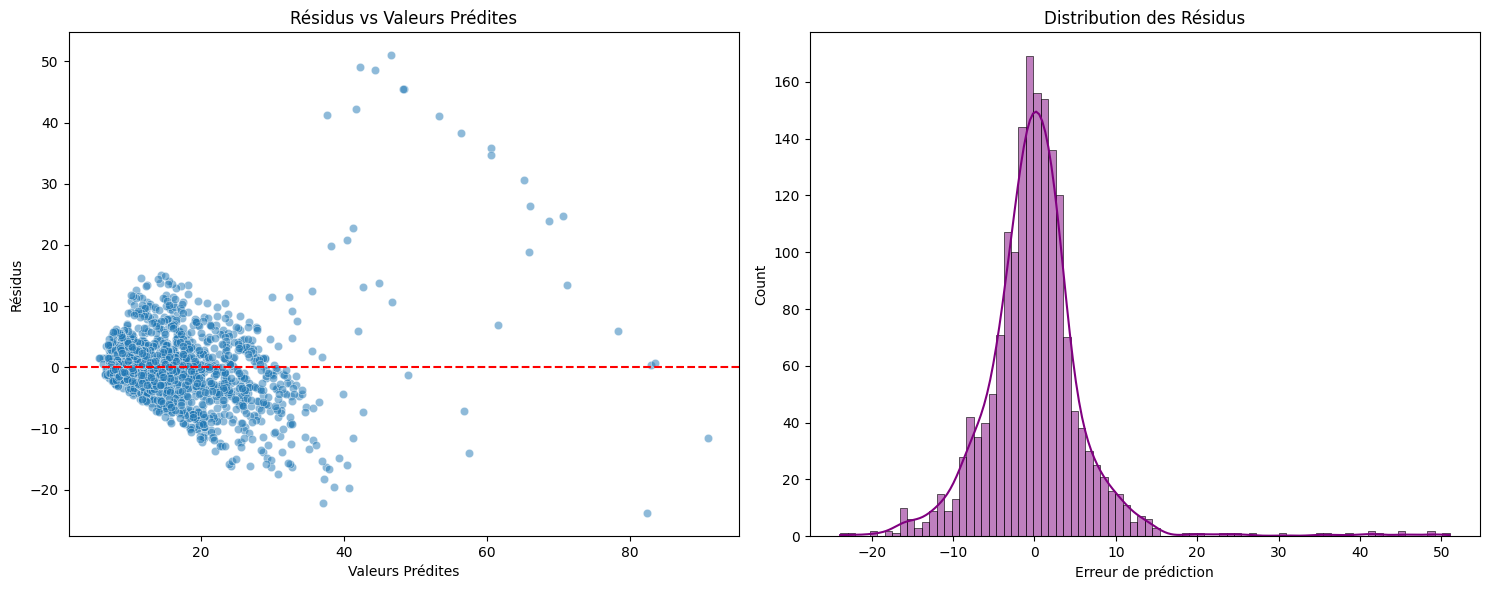

Mean Absolute Error (MAE) : 4.0774
Root Mean Squared Error (RMSE) : 6.3366


In [34]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Calcul des résidus
residus = y - y_pred

# Création de la figure pour l'analyse des résidus
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1. Graphique des Résidus vs Valeurs Prédites (Homoscédasticité)
sns.scatterplot(x=y_pred, y=residus, ax=axes[0], alpha=0.5)
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_title('Résidus vs Valeurs Prédites')
axes[0].set_xlabel('Valeurs Prédites')
axes[0].set_ylabel('Résidus')

# 2. Distribution des Résidus (Normalité)
sns.histplot(residus, kde=True, ax=axes[1], color='purple')
axes[1].set_title('Distribution des Résidus')
axes[1].set_xlabel('Erreur de prédiction')

plt.tight_layout()
plt.show()

# Affichage de quelques métriques d'erreur supplémentaires
mae = np.mean(np.abs(residus))
rmse = np.sqrt(np.mean(residus**2))
print(f'Mean Absolute Error (MAE) : {mae:.4f}')
print(f'Root Mean Squared Error (RMSE) : {rmse:.4f}')

In [35]:
#FIN DU MODULE 1
# Post LK, utiliser Claude comme professeur, expliquer ma démarche
# A chaque module expliquer les limites ici, entrainement insample donc risque de non représentation en out of sample et risque d'overfitting